##### Copyright 2018 The TensorFlow Hub Authors.

Licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Copyright 2018 The TensorFlow Hub Authors. All Rights Reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.
# ==============================================================================

# 使用膨胀 3D CNN 进行动作识别


<table class="tfo-notebook-buttons" align="left">
  <td>     <a target="_blank" href="https://tensorflow.google.cn/hub/tutorials/action_recognition_with_tf_hub"><img src="https://tensorflow.google.cn/images/tf_logo_32px.png">View on TensorFlow.org</a>
</td>
  <td><a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs-l10n/blob/master/site/zh-cn/hub/tutorials/action_recognition_with_tf_hub.ipynb"><img src="https://tensorflow.google.cn/images/colab_logo_32px.png">在 Google Colab 中运行</a></td>
  <td><a target="_blank" href="https://github.com/tensorflow/docs-l10n/blob/master/site/zh-cn/hub/tutorials/action_recognition_with_tf_hub.ipynb">     <img src="https://tensorflow.google.cn/images/GitHub-Mark-32px.png">     在 GitHub 上查看源代码</a></td>
  <td>     <a href="https://storage.googleapis.com/tensorflow_docs/docs-l10n/site/zh-cn/hub/tutorials/action_recognition_with_tf_hub.ipynb"><img src="https://tensorflow.google.cn/images/download_logo_32px.png">下载笔记本</a>   </td>
  <td>     <a href="https://tfhub.dev/deepmind/i3d-kinetics-400/1"><img src="https://tensorflow.google.cn/images/hub_logo_32px.png">查看 TF Hub 模型</a> </td>
</table>

此 Colab 演示如何使用 [tfhub.dev/deepmind/i3d-kinetics-400/1](https://tfhub.dev/deepmind/i3d-kinetics-400/1) 模块识别视频数据中的动作。请点击[这里](https://tfhub.dev/s?module-type=video-classification)，查看有关检测视频中动作的更多模型。

Joao Carreira 和 Andrew Zisserman 在其论文“[Quo Vadis, Action Recognition? A New Model and the Kinetics Dataset](https://arxiv.org/abs/1705.07750)”中对底层模型进行了介绍。该论文于 2017 年 5 月在 arXiv 上发表，并被选为 CVPR 2017 会议论文。源代码已在 [GitHub](https://github.com/deepmind/kinetics-i3d) 上公开。

“Quo Vadis”介绍了一种用于视频分类的新架构，即膨胀 3D 卷积神经网络或 I3D。此架构通过对上述模型进行微调，在 UCF101 和 HMDB51 数据集上取得了目前最优秀的结果。在 Kinetics 上预训练的 I3D 模型也在 CVPR 2017 [Charades 挑战](http://vuchallenge.org/charades.html)中排名第一。

原始模块在 [kinetics-400 数据集](https://www.deepmind.com/open-source/kinetics)上进行了训练，能够识别约 400 种不同动作。这些动作的标签可在[标签映射文件](https://github.com/deepmind/kinetics-i3d/blob/master/data/label_map.txt)中找到。

在此 Colab 中，我们将用它识别来自 UCF101 数据集的视频中的行为。

## 设置

In [3]:
!pip install -q imageio
!pip install -q opencv-python
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


In [4]:
#@title Import the necessary modules
# TensorFlow and TF-Hub modules.
from absl import logging

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow_docs.vis import embed

logging.set_verbosity(logging.ERROR)

# Some modules to help with reading the UCF101 dataset.
import random
import re
import os
import tempfile
import ssl
import cv2
import numpy as np

# Some modules to display an animation using imageio.
import imageio
from IPython import display

from urllib import request  # requires python3

In [5]:
#@title Helper functions for the UCF101 dataset

# Utilities to fetch videos from UCF101 dataset
UCF_ROOT = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"
_VIDEO_LIST = None
_CACHE_DIR = tempfile.mkdtemp()
# As of July 2020, crcv.ucf.edu doesn't use a certificate accepted by the
# default Colab environment anymore.
unverified_context = ssl._create_unverified_context()

def list_ucf_videos():
  """Lists videos available in UCF101 dataset."""
  global _VIDEO_LIST
  if not _VIDEO_LIST:
    index = request.urlopen(UCF_ROOT, context=unverified_context).read().decode("utf-8")
    videos = re.findall("(v_[\w_]+\.avi)", index)
    _VIDEO_LIST = sorted(set(videos))
  return list(_VIDEO_LIST)

def fetch_ucf_video(video):
  """Fetchs a video and cache into local filesystem."""
  cache_path = os.path.join(_CACHE_DIR, video)
  if not os.path.exists(cache_path):
    urlpath = request.urljoin(UCF_ROOT, video)
    print("Fetching %s => %s" % (urlpath, cache_path))
    data = request.urlopen(urlpath, context=unverified_context).read()
    open(cache_path, "wb").write(data)
  return cache_path

# Utilities to open video files using CV2
def crop_center_square(frame):
  y, x = frame.shape[0:2]
  min_dim = min(y, x)
  start_x = (x // 2) - (min_dim // 2)
  start_y = (y // 2) - (min_dim // 2)
  return frame[start_y:start_y+min_dim,start_x:start_x+min_dim]

def load_video(path, max_frames=0, resize=(224, 224)):
  cap = cv2.VideoCapture(path)
  frames = []
  try:
    while True:
      ret, frame = cap.read()
      if not ret:
        break
      frame = crop_center_square(frame)
      frame = cv2.resize(frame, resize)
      frame = frame[:, :, [2, 1, 0]]
      frames.append(frame)

      if len(frames) == max_frames:
        break
  finally:
    cap.release()
  return np.array(frames) / 255.0

def to_gif(images):
  converted_images = np.clip(images * 255, 0, 255).astype(np.uint8)
  imageio.mimsave('./animation.gif', converted_images, duration=40)
  return embed.embed_file('./animation.gif')

In [6]:
#@title Get the kinetics-400 labels
# Get the kinetics-400 action labels from the GitHub repository.
KINETICS_URL = "https://raw.githubusercontent.com/deepmind/kinetics-i3d/master/data/label_map.txt"
with request.urlopen(KINETICS_URL) as obj:
  labels = [line.decode("utf-8").strip() for line in obj.readlines()]
print("Found %d labels." % len(labels))

Found 400 labels.


# 使用 UCF101 数据集

In [7]:
# Get the list of videos in the dataset.
ucf_videos = list_ucf_videos()

categories = {}
for video in ucf_videos:
  category = video[2:-12]
  if category not in categories:
    categories[category] = []
  categories[category].append(video)
print("Found %d videos in %d categories." % (len(ucf_videos), len(categories)))

for category, sequences in categories.items():
  summary = ", ".join(sequences[:2])
  print("%-20s %4d videos (%s, ...)" % (category, len(sequences), summary))


HTTPError: HTTP Error 403: Forbidden

In [7]:
# Get a sample cricket video.
video_path = fetch_ucf_video("v_CricketShot_g04_c02.avi")
sample_video = load_video(video_path)

Fetching https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/v_CricketShot_g04_c02.avi => /tmp/tmp4aza3yq5/v_CricketShot_g04_c02.avi


In [8]:
sample_video.shape

(116, 224, 224, 3)

In [9]:
i3d = hub.load("https://tfhub.dev/deepmind/i3d-kinetics-400/1").signatures['default']

运行 ID3 模型并打印前 5 个动作预测。

In [10]:
def predict(sample_video):
  # Add a batch axis to the sample video.
  model_input = tf.constant(sample_video, dtype=tf.float32)[tf.newaxis, ...]

  logits = i3d(model_input)['default'][0]
  probabilities = tf.nn.softmax(logits)

  print("Top 5 actions:")
  for i in np.argsort(probabilities)[::-1][:5]:
    print(f"  {labels[i]:22}: {probabilities[i] * 100:5.2f}%")

In [11]:
predict(sample_video)

Top 5 actions:
  playing cricket       : 97.77%
  skateboarding         :  0.71%
  robot dancing         :  0.56%
  roller skating        :  0.56%
  golf putting          :  0.13%


现在，尝试一个新的视频，地址为：https://commons.wikimedia.org/wiki/Category:Videos_of_sports

再试试 Patrick Gillett 的[这个视频](https://commons.wikimedia.org/wiki/File:End_of_a_jam.ogv)：

In [12]:
!curl -O https://upload.wikimedia.org/wikipedia/commons/8/86/End_of_a_jam.ogv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 65 55.0M   65 36.0M    0     0   625k      0  0:01:30  0:00:59  0:00:31  527k^C


In [14]:
video_path = "End_of_a_jam.ogv"

In [18]:
sample_video = load_video(video_path)[:100]
sample_video.shape

(70, 224, 224, 3)

In [17]:
video_path = "/content/testVedio.mp4"


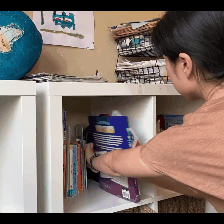

In [19]:
to_gif(sample_video)

In [20]:
predict(sample_video)

Top 5 actions:
  doing laundry         : 19.39%
  mopping floor         : 15.18%
  building cabinet      : 14.96%
  cleaning floor        : 13.70%
  moving furniture      :  8.04%
